# Figure S9 - iMN comparison

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path

# FACS 14 dpi data

## Load data

In [2]:
output_path_FigureS9 = rd.rootdir/'output'/'Figure_S9'

In [3]:
# Directories
datadir = rd.datadir/'data'/'attune'/'nat_attune'/'Reprogram_opt'/'2024.09.27_postsort_EdU-14dpi_0dps'/'export_singlets'

# Store all data in list of dfs which will be converted to df at end
data_14dpi_EdU = list()

# Get all CVs
files = Path(datadir).glob('*.csv') 
for i, file in enumerate(files):

    # Extract metadata from csv title
    match = re.search(
        'export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)

    df = pd.read_csv(file, header=0)
    df['rep'] = int(match.group('rep'))
    df['cond'] = match.group('cond')
    
    data_14dpi_EdU.append(df)


# Convert list of dfs into single df
data_14dpi_EdU = pd.concat(data_14dpi_EdU, ignore_index=True)

# Remove negative data
data_14dpi_EdU_all = data_14dpi_EdU.loc[(data_14dpi_EdU['eGFP-H'] > 0)]

# Split into cond and non
data_14dpi_EdU = data_14dpi_EdU_all.loc[data_14dpi_EdU_all.cond == 'NILRIDD']
data_14dpi_EdU_ctrl = data_14dpi_EdU_all.loc[data_14dpi_EdU_all.cond == 'Ctrl-neg']

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_38604\1727407881.py:13: SyntaxWarning: invalid escape sequence '\d'
  'export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)


# Load desNb EGFP data

Load data from 3/10/25

In [5]:
# Base dir for data files
base_datadir = rd.datadir /'data'/'attune'/ "nat_attune" / "desNb-circuits" / "2025.03.10_desNb-reseed_14dpi"

# List of puro conc + directories
dir_list = ['0nguL', '48-96-nguL']

# Store all data in list of dfs which will be converted to df at end
df_all = list()
# for (dir, puro) in dirs.items():
for dir in dir_list:

     # Load as df and note header is on 0th row
    df = rd.flow.load_csv_with_metadata(
        base_datadir/dir/'export_singlets', base_datadir/f'well_metadata_{dir}.yaml')

    df_all.append(df)

# Convert list of dfs into single df
df_all = pd.concat(df_all, ignore_index=True)

# Remove negative data
df = df_all.loc[( df_all["eGFP-A"] > 0) & (df_all["mRuby2-A"] > 0)]

# Convert puro to int
df = df.astype({'puro': 'int'})
# Just get desNb(EGFP)
df_desNb = df.loc[df.cond == 'desNb(EGFP)']
# Get rid of rep 1 (cell death)
df_desNb = df_desNb.loc[df_desNb.rep != 1]

Load data from 1/5/24

In [6]:
# Base dir for data files
base_datadir = rd.datadir /'data'/'attune'/ "nat_attune" / "desNb-circuits" / "2024.01.05_seedtitrate_7dpt"
# figure path

# List of puro conc + directories
dirs = {'0ugmL': 0, '96ugmL':96}

# Store all data in list of dfs which will be converted to df at end
df_all = list()
for (dir, puro) in dirs.items():

     # Load as df and note header is on 0th row
    df = rd.flow.load_csv_with_metadata(
        base_datadir/dir/'export_singlets', base_datadir/'well_metadata.yaml')

    df['puro'] = puro
    df_all.append(df)

# Convert list of dfs into single df
df_all = pd.concat(df_all, ignore_index=True)

# Remove negative data
df = df_all.loc[( df_all["eGFP-A"] > 0) & (df_all["mRuby2-A"] > 0)]

# Convert puro to int
df = df.astype({'puro': 'int'})

# Just get desNb(EGFP) and rename to match desNb(EGFP)
df_desNb_1 = df.loc[df.cond == 'desNb-puro-mRuby2']
df_desNb_1['cond'] = 'desNb(EGFP)'
# Just get 2.5k seed to match
df_desNb_1 = df_desNb_1.loc[df_desNb_1.seedNum == '2.5k']
df_desNb_1['rep'] = 1
# Get rid of unnecessary columns
df_desNb_1.drop(['celltype', 'seedNum'], axis='columns', inplace=True)

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_38604\385416246.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_desNb_1['cond'] = 'desNb(EGFP)'


In [7]:
data_list = [data_14dpi_EdU_ctrl[(data_14dpi_EdU_ctrl['cond'] == 'Ctrl-neg')], data_14dpi_EdU, df_desNb.loc[df_desNb.puro == 96], df_desNb_1.loc[df_desNb_1.puro == 96],]
data_both = pd.concat(data_list, ignore_index=True)

# Figure S9E

**Figure S9E - single cell distribution**

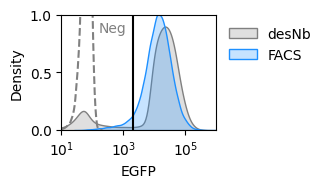

In [9]:
# Plot eGFP-H
fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))
x = 'eGFP-H'
hue = 'cond'
palette = {'desNb(EGFP)': 'dodgerblue', 'NILRIDD': 'grey'}
hue_order = ['desNb(EGFP)', 'NILRIDD']

# Threshold for iMNs
eGFP_H_thresh = 2*10**3

# Downsample to 10,000 cells from NIL
small_data = data_both[data_both.cond != 'Ctrl-neg']
sns.kdeplot(
    ax=ax, data=small_data, x=x,
    hue=hue, hue_order=hue_order, palette=palette,
    log_scale=(True, False), fill=True, common_norm=False)

# Plot neg ctrl
color = 'grey'
sns.kdeplot(data=data_both[(data_both['cond'] == 'Ctrl-neg')], x=x, common_norm=False,
            ax=ax, log_scale=(True, False), color=color, fill=False, linestyle='--')
ax.annotate('Neg', (0.33, 0.85), color=color, xycoords='axes fraction', ha='center')


# legend
lmap = {'desNb(EGFP)': 'desNb', 'NILRIDD': 'FACS'}
ax.legend(['desNb', 'FACS'])
# h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Title
# plt.title('NIL+DDRR, 0 dps')
# Adjust limits
eGFP_lim = (10, 10**6)
ax.set_xlim(eGFP_lim)
ax.set_ylim((0, 1))
ax.set_yticks([0, .5, 1])
ax.axvline(eGFP_H_thresh, 0, 1, color='black')
ax.set_xlabel('EGFP')

plottitle = f'Figure_S9E_single_cell_distribution.svg'
plt.savefig(rd.outfile(output_path_FigureS9/plottitle),bbox_inches='tight')   